In [ ]:
# If running inside Jupyter / Colab
!pip install -q \
    pandas \
    setfit \
    ollama \
    rouge-score \
    requests \
    sentence-transformers \
    umap-learn \
    matplotlib \
    datasets

In [33]:
import pandas as pd
import sys
sys.path.append("./../src")
import utils
from setfit import SetFitModel
import ollama
from rouge_score import rouge_scorer
import requests
import json
from sentence_transformers import SentenceTransformer
import umap
import matplotlib.pyplot as plt
from datasets import load_dataset
random_seed=38


In [47]:
UK_SMALL='./../data/uk_small.csv'
df_1=pd.read_csv(UK_SMALL)

In [84]:
df_1.head()

,date,agenda,speaker,party,text,iso3country,policyarea,year
0,12/01/2009,Defence,Simon Hughes,LibDem,What recent assessment he has made of the risk...,GBR,16,2009
1,12/01/2009,Defence,John Hutton,Lab,"Before I begin, I am sure that the whole House...",GBR,19,2009
2,12/01/2009,Defence,John Hutton,Lab,"They were Sergeant Christopher Reed, of 6th Ba...",GBR,16,2009
3,12/01/2009,Defence,John Hutton,Lab,Our thoughts and prayers are likewise with the...,GBR,19,2009
4,12/01/2009,Defence,John Hutton,Lab,Providing effective help and support for servi...,GBR,16,2009


In [ ]:
#Download the dataset from huggingface
dataset1 = load_dataset("andreacristiano/uk_parliament")
df1 = dataset1['train'].to_pandas()

In [48]:
records = {
    "nuclear":{
        'keywords':[
            "Power plant",
            "Nuclear power generation",
            "Decommissioning",
            "Nuclear fuel",
            "Radioactivity",
            "Radioactive waste",
            "Energy base load power source",
            "Fukushima",
            "Chernobyl",
            "Daiichi Nuclear Power Plant",
            # General nuclear-energy vocabulary
            "Nuclear reactors",
            "Pressurised Water Reactor",
            "Advanced Gas-cooled Reactor",
            "Small Modular Reactors",
            "Advanced Modular Reactors",
            "Nuclear fission",
            "Nuclear fusion",
            "Uranium enrichment",
            "Fuel reprocessing",
            "Spent fuel management",
            "Nuclear contamination",
            "Nuclear decontamination",
            "Radiation leakage",
            # UK-specific nuclear infrastructure
            "Hinkley Point C",
            "Sizewell C",
            "Wylfa Newydd",
            "Oldbury",
            "Bradwell B",
            "Sellafield",
            "Dounreay",
            "Magnox reactors",
            "Office for Nuclear Regulation",
            "Nuclear Decommissioning Authority",
            "Energy Security Strategy",
            "Regulated Asset Base model",
            "RAB model",
            # Political and policy themes
            "Nuclear financing",
            # Risk and crisis terms
            "Nuclear meltdown",
            "Core containment",
            "Emergency cooling system",
            # Geopolitical and supply chain
            "Uranium supply chain",
            "Nuclear cooperation agreements",
            "Russian uranium",
            ],
        'policyarea':[7, 8],
        
        },

    "climate change": {
        'keywords':
            ["global warming",
             "greenhouse gases", "carbon emissions", "renewable energy", "sustainability",  
             "climate mitigation", "COP26", "Paris Agreement",
             "climate change",
            "net zero",
            "carbon neutrality",
            "emissions reduction",
            "decarbonisation",
            "fossil fuels",
            "energy transition",
            "clean energy",
            "climate adaptation",
            "climate resilience",
            "extreme weather",
            "sea level rise",
            "biodiversity loss",
            "deforestation",
            "carbon pricing",
            "carbon tax",
            "emissions trading",
            "climate justice",
            "just transition",
            "IPCC"],
        'policyarea':[8],
        
        },
    "Gaza":{ 
        'keywords': [
            # Israeli political figures
            "Netanyahu",
            "Benjamin Netanyahu",
            "Ehud Olmert",
            "Ariel Sharon",
            "Ehud Barak",
            "Tzipi Livni",
            "Naftali Bennett",
            "Yair Lapid",
            "Avigdor Lieberman",
            "Shimon Peres",
            "Isaac Herzog",
            "Reuven Rivlin",
            "Benny Gantz",
            "Yoav Gallant",
            "Ben Gvir",
            "Zionism", "Zionist", "anti-zionist", "anti-zionism",

            # Palestinian political figures
            "Mahmoud Abbas",
            "Abu Mazen",
            "Ismail Haniyeh",
            "Yahya Sinwar",
            "Marwan Barghouti",
            "Saeb Erekat",
            "Mohammad Shtayyeh",
            "Khaled Mashal",
            "Ahmed Yassin",
            "Mohammed Deif",

            # Israeli institutions / organisations
            "Knesset",

            "Israel Defense Forces",
            "Shin Bet",
            "Mossad",
            "Likud",
            "Yesh Atid",
            "Blue and White",
            "Kadima",
            "Religious Zionism party",
            "Shas",
            "Meretz",

            # Palestinian institutions / organisations
            "Palestine Liberation Organization",
            "Fatah",
            "Hamas",
            "Popular Front for the Liberation of Palestine",
            "PFLP",
            "Al-Qassam Brigades",
            "Palestinian Legislative Council",

            # Key places (Gaza / Israel)
            "Gaza City",
            "Rafah",
            "Khan Younis",
            "Jabalia",
            "Beit Hanoun",
            "Deir al-Balah",
            "Shuja'iyya",
            "Nuseirat",
            "Beit Lahia",
            "Al-Shifa Hospital",

            # Key places (Israel)
            "Sderot",
            "Ashkelon",
            "Ashdod",
            "Beersheba",
            "Tel Aviv",
            "Jerusalem",
            "West Jerusalem",
            "East Jerusalem",
            "Haifa",
            "Eilat",

            # Crossings and checkpoints
            "Erez Crossing",
            "Kerem Shalom Crossing",
            "Rafah Crossing",
            "Qalandia",
            "Allenby Bridge Crossing",
            "Gilo checkpoint",

            # Named military operations (appear frequently in UK Parliament debates)
            "Operation Cast Lead",
            "Operation Pillar of Defense",
            "Operation Protective Edge",
            "Operation Guardian of the Walls",
            "Operation Breaking Dawn",
            "Operation Iron Swords",
            "Operation Summer Rains",
            "Operation Autumn Clouds",

            # International actors mentioned regarding the conflict
            "UNRWA",
            "UN Human Rights Council",
            "Quartet on the Middle East",
            

            # Other region-specific named entities
            "Al-Aqsa Mosque",
            "Temple Mount",
            "Haram al-Sharif",
            "Sheikh Jarrah",
            "Hebron",
            "Nablus",
            "Ramallah",
            "Bethlehem",
            "Jenin",

            # NGOs / rights groups mentioned often
            "B'Tselem",
            "Breaking the Silence",
            "ICRC"
        ],
        'policyarea':[16, 18, 19],
        
    },
    'migration':{
        'keywords':[],
        'policyarea':[9]
    }
    }

In [68]:
class StanceDetector:
    
    
    """
    A class for detecting and analyzing political stances in parliamentary speeches.
    
    WORKFLOW:
    1. Load parliamentary speeches dataset
    2. Filter speeches by topic (using keywords and policy areas)
    3. Classify sentences as opinionated or non-opinionated
    4. Keep only opinionated sentences for analysis
    5. Summarize each speaker's stance on the topic
    6. Generate stance anchors (opposing viewpoints)
    7. Create UMAP visualizations to map political positions
    
    DATA STRUCTURE:
    The class stores topics in a record dictionary:
    {
        "nuclear": {
            'keywords': [...],           # Words to search for
            'policyarea': [7, 8],        # Policy area codes
            'df_filtered': ...,          # Speeches matching topic
            'df_classified': ...,        # Opinionated sentences only
            'df_summarized_speaker': ... # Summarized stances per speaker
        }
    }
    
    INPUT DATASET COLUMNS:
    [ 'date', 'agenda', 'speaker', 'party', 'text', 'policyarea']
    """
    __record=None
    __speeches_df=None

    def __init__( self, speech,records, cl_model_hf="andreacristiano/stancedetection"):

        """
        Initialize the StanceDetector.
        
        Args:
            speech: DataFrame containing all parliamentary speeches
            records: Dictionary to store topic-specific data
            cl_model_hf: HuggingFace model for opinion classification
        """

        self.__speeches_df = speech
        self.__record= records    
        self.model= SetFitModel.from_pretrained(cl_model_hf)

    # ==================== GETTER METHODS ====================
    def get_records(self):
        return self.__record
    
    def get_speeches(self):
        return self.__speeches_df
    
    def get_filtered_speeches(self, topic):
        return self.__record[topic]['df_filtered']
    
    def get_classified_speeches(self, topic):
        return self.__record[topic]['df_classified']

    # ==================== UTILITY METHODS ====================

    def format_discussion(self,agenda, date):
        
        """
        Format a parliamentary discussion as a dialogue.
        
        Args:
            agenda: The agenda item identifier
            date: The date of the discussion
            
        Returns:
            String formatted as:
            speaker1 (party1): text
            speaker2 (party2): text
            ...
        """
        # Get all sentences from this specific discussion
        discussion_df = self.__speeches_df[
            (self.__speeches_df['agenda'] == agenda) & 
            (self.__speeches_df['date'] == date)
        ].copy()
       
        if discussion_df.empty:
            return f"No discussion found for agenda '{agenda}' on date '{date}'."

        # Sort by speechnumber and sentencenumber to maintain chronological order
        discussion_df.sort_values(by=['speechnumber', 'sentencenumber'], inplace=True)

        # Group sentences belonging to the same speech (same speechnumber, speaker, and party)
        grouped = (
            discussion_df
            .groupby(['speechnumber', 'speaker', 'party'])['text']
            .apply(' '.join)
            .reset_index()
        )

        # Format each speech as "Speaker (Party): text"
        formatted_lines = [f"{row['speaker']} ({row['party']}): {row['text']}" for _, row in grouped.iterrows()]

        # Join everything into one formatted discussion
        return "\n".join(formatted_lines)

        
    def add_record(self, topic, keywords, policyarea):
        """
        Add a new topic to track.
        
        Args:
            topic: Name of the topic (e.g., 'nuclear', 'immigration')
            keywords: List of keywords to search for in speeches
            policyarea: List of policy area codes to filter by
        """
        self.__record[topic] = {
            'keywords':keywords,
            'policyarea':policyarea,
        }

    def __get_keywords_policyarea(self,topic):
        """
        Internal method to retrieve keywords and policy areas for a topic.
        
        Returns:
            Tuple of (keywords_list, policyarea_list)
        """
        return self.__record[topic]['keywords'], self.__record[topic]['policyarea']
    

    # ==================== MAIN WORKFLOW METHODS ====================

    def filter_speeches(self, topic, years=None):
        """
        Filter speeches by topic, and optionally by year.
        
        This is STEP 1 of the analysis workflow.
        Applies three filters:
        1. Year filter (optional)
        2. Policy area filter
        3. Keyword filter (speeches must contain at least one keyword)
        
        Args:
            topic: The topic to filter for
            years: Optional list of years to include (e.g., [2019, 2020])
            
        Returns:
            DataFrame of filtered speeches
        """
        print("Filtering speeches for topic:", topic)

        keywords, policyarea = self.__get_keywords_policyarea(topic)

        # Start from full dataset
        df = self.__speeches_df.copy()

         # --- Year filtering (optional) ---
        if years is not None:
            df = df[df['year'].isin(years)]

        # --- Policy area filtering ---
        if policyarea:
            df = df[df['policyarea'].isin(policyarea)]

        # --- Keyword filtering ---
        if topic!='migration':
            df = df[df['text'].str.contains('|'.join(keywords), case=False, na=False)]

        # Store result
        self.__record[topic]['df_filtered'] = df

        print(
            f"Number of speeches after filtering for topic '{topic}'"
            + (f" in years {years}" if years is not None else "")
            + f": {len(df)}"
        )

        return df

    def classify_filtered_sentences(self, topic):
        """
        Classify sentences as opinionated or non-opinionated.
        
        This is STEP 2 of the analysis workflow.
        - Uses few shot model to classify each sentence
        - Keeps only opinionated sentences
        - Removes speakers with only one sentence (insufficient data) to reduce noise
        
        Args:
            topic: The topic to classify
            
        Returns:
            DataFrame containing only opinionated sentences
        """
        print("Classifying filtered speeches for topic:", topic)

        #Extract the filtered dataframe
        df_filtered = self.__record[topic]['df_filtered']

        # Get the texts to classify
        texts = df_filtered['text'].tolist()

        # Perform classification
        predictions = self.model.predict(texts)

        # Add predictions as a new column
        df_filtered['classification'] = predictions

        # Keep only opinionated sentences
        df_classified = df_filtered[df_filtered['classification'] == 'opinion']

        # Remove speakers with only one datapoint
        speaker_counts = df_classified['speaker'].value_counts()
        valid_speakers = speaker_counts[speaker_counts > 1].index
        df_classified = df_classified[df_classified['speaker'].isin(valid_speakers)]

        # Store result
        self.__record[topic]['df_classified'] = df_classified

        print(f'"Number of opinionated speeches for {topic}: {len(df_classified)}')
        return df_classified
    

    def __get_speaker_sentences(self, speaker_name, topic):
        """
        Internal method to get all opinionated sentences from one speaker on a topic.
        
        Args:
            speaker_name: Name of the speaker
            topic: The topic to retrieve sentences for
            
        Returns:
            DataFrame of sentences from this speaker about this topic
        """
        classified_df = self.__record[topic]['df_classified']
        return classified_df[classified_df['speaker'] == speaker_name]
        
    
    def classify_filtered_sentences(self, topic):
        """
        IN: filtered dataframe about a topic
        OUT: classified dataframe containing opinionated sentences only
            + a new column 'classification' in filtered dataframe
            + speakers with only one datapoint removed
        """
        print("Classifying filtered speeches for topic:", topic)

        #Extract the filtered dataframe
        df_filtered = self.__record[topic]['df_filtered']

        # Get the texts to classify
        texts = df_filtered['text'].tolist()

        # Perform classification
        predictions = self.model.predict(texts)

        # Add predictions as a new column
        df_filtered['classification'] = predictions

        # Keep only opinionated sentences
        df_classified = df_filtered[df_filtered['classification'] == 'opinion']

        # --- Remove speakers with only one datapoint ---
        speaker_counts = df_classified['speaker'].value_counts()
        valid_speakers = speaker_counts[speaker_counts > 1].index
        df_classified = df_classified[df_classified['speaker'].isin(valid_speakers)]

        # Store result
        self.__record[topic]['df_classified'] = df_classified

        print(f'Number of opinionated speeches for {topic}: {len(df_classified)}')
        return df_classified
    

    def __get_speaker_sentences(self, speaker_name, topic):
        """
        Retrieve all sentences spoken by a specific speaker on a given topic.
        
        """
        classified_df = self.__record[topic]['df_classified']
        return classified_df[classified_df['speaker'] == speaker_name]
        
    
    def sum_member_speeches(self, speaker_name, topic, model_name='gemma3'):
        
        """
        Summarize one speaker's stance on a topic using an LLM.
        
        This is STEP 3a (per speaker) of the analysis workflow.
        - Collects all opinionated sentences from the speaker
        - Sends them to an LLM for summarization
        - Returns a one-sentence summary of their stance
        
        Args:
            speaker_name: Name of the speaker to summarize
            topic: The topic to summarize about
            model_name: Ollama model to use for summarization
            
        Returns:
            DataFrame with columns: summary, party, speaker
        """

        # Use verbose topic description for better LLM understanding
        topic_verbose=topic
        if topic=='nuclear':
            topic_verbose = 'the use of nuclear energy as an energy source for the future'
        
        # Get all sentences from this speaker about this topic
        speaker_sentences = self.__get_speaker_sentences(speaker_name, topic)

        # Combine all sentences into one text block using \n as separator
        full_text = "\n".join(speaker_sentences['text'].tolist())

        # Prompt for LLM: summarize the speaker's stance
        context_prompt=f"Based on the politician's statements in the following parliamentary speeches, infer and summarize this politician's stance on {topic_verbose}. This summary is intended for those who have little knowledge of British politics. Please summarize in a way that is easy to understand even for those who are not interested in politics. \n{full_text}."

        # System prompt: ensure factual, concise output
        sys_prompt="You are an expert in UK parliamentary politics. Provide only a single, clear, concise, and purely factual summary sentence of the politician's stance. Do not use introductory phrases like 'Okay,', 'Based on,', or 'From this,'. Do not use colloquial language, filler words, or explanations. Output the summary sentence directly."
        
        # Prepare the request to Ollama API
        payload = {
            "model": model_name,
            "prompt": context_prompt,
            "system": sys_prompt,
            "stream": False,
            "options": {
                "seed": random_seed
            }
        }
        try:
            # Call Ollama API (default runs on localhost:11434)
            response = requests.post(
                "http://localhost:11434/api/generate",
                json=payload,
                timeout=60
            )
            response.raise_for_status()
            
            # Extract the summary from response
            summary = response.json()['response'].strip()
            
        except requests.exceptions.RequestException as e:
            print(f"\nError generating summary for speaker {speaker_name}: {e}")
            summary = "ERROR: {str(e)}"

        # Return as a single-row DataFrame
        return pd.DataFrame([{
            'summary': summary,
            'party': speaker_sentences['party'].iloc[0],
            'speaker': speaker_name
        }])

    def summarize_all_sentences(self, topic, model_name='gemma3'):
        """
        Summarize stances for all speakers on a topic.
        
        This is STEP 3 of the analysis workflow.
        - Calls sum_member_speeches() for each speaker
        - Combines all summaries into one DataFrame
        - Removes any failed summaries
        
        Args:
            topic: The topic to summarize
            model_name: Ollama model to use
            
        Returns:
            DataFrame with columns: summary, party, speaker
        """

        # Get all unique speakers who have opinionated sentences
        classified_df=self.__record[topic]['df_classified']
        speakers = classified_df['speaker'].unique()

        # Summarize each speaker's stance
        summaries = []
        for speaker in speakers:
            summary_df = self.sum_member_speeches(speaker, topic, model_name=model_name)
            summaries.append(summary_df)

        # Combine all summaries
        result_df = pd.concat(summaries, ignore_index=True)
        self.__record[topic]['df_summarized_speaker'] = result_df

        # Remove any rows where LLM failed to generate a proper summary (they usually start with 'Please provide')
        self.__record[topic]['df_summarized_speaker'] = self.__record[topic]['df_summarized_speaker'][~self.__record[topic]['df_summarized_speaker']['summary'].str.startswith('Please provide')]
        print("Summarization completed for topic:", topic)
        return self.__record[topic]['df_summarized_speaker']

    def generate_anchors(self, topic, model_name='gemma3'):

        """
        Generate stance anchors (opposing viewpoints) for a topic.
        
        This is STEP 4 of the analysis workflow.
        - Takes all speaker summaries
        - Uses LLM to identify key issues and opposing views
        - Returns structured anchors (pro/con positions)
        
        Args:
            topic: The topic to generate anchors for
            model_name: Ollama model to use
            
        Returns:
            List of dictionaries with keys: topic, pro, con
        """
        print("Generating stance anchors for topic:", topic)
        summarizations = self.__record[topic]['df_summarized_speaker']

        # Concatenate all summaries into one text
        text = "\n".join(summarizations['summary'].dropna().astype(str))

        # Prompt LLM to identify issues and opposing views
        prompt = f"""
            Below is a text summarizing the stance on {topic} of several legislators extracted from the parliamentary proceedings.
            Please use this text as a basis for identifying issues related to this topic, and describe the polar opposing views on these issues.

            Response Format (Please be sure to respond in this format)
            Issue: Outline of the issue
            For: Opinion in favor of the issue
            Against: Opinion against the issue

            Text:
            {text}
            """

        # Request structured JSON output from Ollama
        response = ollama.chat(
            model=model_name,
            messages=[{"role": "user", "content": prompt}],
            format={
                "type": "array",
                "items": {
                    "type": "object",
                    "properties": {
                        "topic": {"type": "string"},
                        "pro": {"type": "string"},
                        "con": {"type": "string"}
                    },
                    "required": ["topic", "pro", "con"]
                }
            },
            options={"temperature": 0, 'seed': random_seed}
        )

        content = response["message"]["content"]

        return json.loads(content)
    
    def compute_umap_embeddings(self,
                           topic,
                           anchors,
                           model_name="Qwen/Qwen3-Embedding-0.6B",
                           n_components=2,
                           n_neighbors=10,
                           min_dist=0.1,
                           metric="cosine",):
        """
        Create UMAP embeddings to visualize speaker positions on a topic.
        
        This is STEP 5 of the analysis workflow.
        - Converts speaker summaries to numerical embeddings
        - Includes stance anchors (pro/con) in the embedding space
        - Reduces to 2D using UMAP for visualization
        
        Args:
            topic: The topic to visualize
            anchors: Dictionary with 'pro' and 'con' stance descriptions
            model_name: SentenceTransformer model for embeddings
            n_components: Number of UMAP dimensions (usually 2 for plotting)
            n_neighbors: UMAP parameter (affects local vs global structure)
            min_dist: UMAP parameter (affects point spacing)
            metric: Distance metric for UMAP
            
        Returns:
            Dictionary containing:
            - 'df': DataFrame with UMAP coordinates (umap_x, umap_y)
            - 'reduced_embeddings': Full UMAP array (speakers + anchors)
            - 'reduced_anchors': UMAP coordinates for pro/con anchors
            - 'anchors': The input anchor dictionary
        """

        print("Computing UMAP embeddings for topic:", topic)
        
        # Get speaker summaries
        sum_df = self.__record[topic]['df_summarized_speaker'].copy()
        summaries = sum_df["summary"].tolist()

        # Extract anchor texts (pro and con positions)
        anchor_texts = [anchors['pro'], anchors['con']]
        
        # Load embedding model
        model = SentenceTransformer(model_name)
        
        # Embed both speaker summaries AND anchors together
        # (This ensures they're in the same embedding space)
        all_texts = summaries + anchor_texts
        embeddings = model.encode(all_texts, show_progress_bar=True)
        

        # Reduce embeddings to 2D using UMAP
        reducer = umap.UMAP(
            n_components=n_components,
            n_neighbors=n_neighbors,
            min_dist=min_dist,
            metric=metric,
            random_state=random_seed
        )
        reduced_embeddings = reducer.fit_transform(embeddings)
        
        # Split back into speeches and anchors
        reduced_speeches = reduced_embeddings[:len(summaries)]
        reduced_anchors = reduced_embeddings[len(summaries):]

        # Add UMAP coordinates to the speaker DataFrame
        sum_df["umap_x"] = reduced_speeches[:, 0]
        sum_df["umap_y"] = reduced_speeches[:, 1]

        return {
            'df': sum_df,
            'reduced_embeddings': reduced_embeddings,
            'reduced_anchors': reduced_anchors,
            'anchors': anchors
        }

    def plot_umap_party_averages(self,
                             umap_data,                            
                             show_speeches=True,
                             show_party_averages=True,
                             show_speaker_labels=True,
                             label_fontsize=8):
        """
        Visualize speaker positions and party centroids on a 2D UMAP plot.
        
        This is STEP 6 (visualization) of the analysis workflow.
        - Plots individual speakers colored by party
        - Shows party average positions (centroids)
        - Displays stance anchors (pro/con) as black diamonds
        - Includes anchor descriptions below the plot
        
        Args:
            umap_data: Output from compute_umap_embeddings()
            show_speeches: Whether to show individual speaker points
            show_party_averages: Whether to show party centroid markers
            show_speaker_labels: Whether to show speaker names on datapoints
            label_fontsize: Font size for speaker labels
        """
        # Extract data from the UMAP results
        sum_df = umap_data['df']
        reduced_anchors = umap_data['reduced_anchors']
        anchors = umap_data['anchors']
        anchor_labels = ['pro', 'con']

        # Calculate party centroids (average UMAP position per party)
        party_centroids = (
            sum_df
            .groupby("party")
            .agg({
                "umap_x": "mean",
                "umap_y": "mean",
                "party": "size"  # Count speeches per party
            })
            .rename(columns={"party": "speech_count"})
            .reset_index()
        )

        # Assign colors to parties
        unique_parties = sorted(sum_df["party"].dropna().unique())
        party_to_color = {party: i for i, party in enumerate(unique_parties)}
        cmap = plt.get_cmap("tab10")

        # Create the plot
        fig, ax = plt.subplots(figsize=(12, 12))

        # Plot each party's data
        for party in unique_parties:
            color = cmap(party_to_color[party])

            # Plot individual speakers if requested
            if show_speeches:
                mask = sum_df["party"] == party
                party_data = sum_df.loc[mask]
                
                ax.scatter(
                    party_data["umap_x"],
                    party_data["umap_y"],
                    alpha=0.85,
                    color=color,
                    label=party
                )
                
                # Add speaker labels to each datapoint
                if show_speaker_labels:
                    for _, row in party_data.iterrows():
                        ax.annotate(
                            row['speaker'],
                            xy=(row['umap_x'], row['umap_y']),
                            xytext=(3, 3),  # Small offset from the point
                            textcoords='offset points',
                            fontsize=label_fontsize,
                            alpha=0.7,
                            color=color
                        )

            # Plot party centroid if requested
            if show_party_averages:
                centroid = party_centroids[party_centroids["party"] == party]
                # Marker size scales with number of speeches
                marker_size = 100 + centroid["speech_count"].values[0] * 80
                ax.scatter(
                    centroid["umap_x"],
                    centroid["umap_y"],
                    s=marker_size,
                    color=color,
                    edgecolor="black",
                    linewidth=1.2,
                    zorder=5  # Draw on top of individual points
                )

        # Plot stance anchors (pro/con positions)
        if reduced_anchors is not None:
            ax.scatter(
                reduced_anchors[:, 0],
                reduced_anchors[:, 1],
                s=200,
                color='black',
                marker='D',  # Diamond shape
                edgecolor='white',
                linewidth=1.5,
                label='Stance Anchors',
                zorder=10  # Draw on top of everything
            )

            # Add labels to anchors with arrows
            for x, y, label in zip(
                reduced_anchors[:, 0],
                reduced_anchors[:, 1],
                anchor_labels
            ):
                ax.annotate(
                    label.upper(),
                    xy=(x, y),
                    xytext=(10, 10),
                    textcoords='offset points',
                    fontsize=9,
                    bbox=dict(
                        boxstyle='round,pad=0.3',
                        facecolor='yellow',
                        alpha=0.7
                    ),
                    arrowprops=dict(
                        arrowstyle='->',
                        connectionstyle='arc3,rad=0',
                        lw=1
                    )
                )

        # Add titles and labels
        ax.set_title(f"UMAP Party Averages – {anchors['topic']}")
        ax.set_xlabel("UMAP Dimension 1")
        ax.set_ylabel("UMAP Dimension 2")

        # Add legend
        ax.legend(
            title="Parties & Anchors",
            bbox_to_anchor=(1.05, 1),
            loc="upper left"
        )

        # Add anchor descriptions at the bottom of the figure
        anchor_text = (
            f"*PRO*: {anchors['pro']}\n\n"
            f"*CON*: {anchors['con']}"
        )

        fig.text(
            0.02,  # x position (left side)
            0.02,  # y position (bottom)
            anchor_text,
            ha="left",
            va="bottom",
            fontsize=14,
            wrap=True
        )

        # Make space at the bottom for anchor text
        plt.subplots_adjust(bottom=0.30)
        plt.show()



In [73]:
def politician_stance(summarizations, name):
    summary = summarizations[summarizations['speaker'] == name]['summary']
    if not summary.empty:
        #return summary.iloc[0]
        print(f"{name}: {summary.iloc[0]}")
    else:
        return f"No summary found for {name}."

In [73]:
#for testing purposes only  
def extract_keywords_from_sentence(keywords, sentence, topic):
    """
    Extract keywords that appear in a given sentence.
    
    Parameters:
    -----------
    sentence : str
        The sentence to search for keywords
    keywords : list
        List of keywords to search for
    
    Returns:
    --------
    list
        List of keywords found in the sentence
    """
    # Convert sentence to lowercase for case-insensitive matching
    sentence_lower = sentence.lower()
    
    # Find keywords that appear in the sentence
    found_keywords = []
    kws=keywords
    for keyword in kws:
        if keyword.lower() in sentence_lower:
            found_keywords.append(keyword)
    
    return found_keywords

def summarize_parliamentary_speeches(classified_df,keywords,  model_name, num_samples, topic):
    """
    Summarize random samples from UK parliamentary speeches using Ollama.
    Computes ROUGE scores, extracts keywords, and displays results.
    
    Parameters:
    -----------
    we start on a classified dataframe
    model_name : str
        Name of the Ollama model to use (e.g., 'llama2', 'mistral')
    num_samples : int
        Number of random samples to extract and summarize
    topic : str
        The topic that all speeches are about (e.g., 'climate change', 'Brexit')
    keywords : list
        List of keywords to search for in each sentence
    
    Returns:
    --------
    pd.DataFrame
        DataFrame with columns: 'original_text', 'summary', 'keywords', 'rouge1', 'rouge2', 'rougeL'
    """
    # Extract random samples keeping only the 'text' column

    samples = classified_df[['text']].sample(n=num_samples, random_state=None)
    
    #TODO: generalize system prompt for every parliament
    # System prompt for UK parliamentary context with focus on stance
    system_prompt = f"""You are summarizing speeches from the UK Parliament about {topic}. 
    Focus on capturing the speaker's stance or position regarding {topic}. 
    Provide brief, concise summaries that clearly indicate whether the speaker supports, opposes, or has a nuanced view on {topic}.
    Keep summaries to 1-2 sentences maximum. if the speech does not express any stance on {topic}, reply NO"""
    
    # Initialize ROUGE scorer
    scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
    
    results = []
    
    print("=" * 100)
    print(f"PARLIAMENTARY SPEECH SUMMARIZATION WITH ROUGE SCORES")
    print(f"TOPIC: {topic}")
    print("=" * 100)
    
    for idx, row in enumerate(samples.iterrows(), 1):
        speech_text = row[1]['text']
        
        # Extract keywords from the original text
        found_keywords = extract_keywords_from_sentence(keywords,speech_text, topic)
        
        # Prepare the request to Ollama API
        payload = {
            "model": model_name,
            "prompt": f"Summarize this parliamentary speech about {topic}, focusing on the speaker's stance:\n\n{speech_text}",
            "system": system_prompt,
            "stream": False
        }
        
        try:
            # Call Ollama API (default runs on localhost:11434)
            response = requests.post(
                "http://localhost:11434/api/generate",
                json=payload,
                timeout=60
            )
            response.raise_for_status()
            
            # Extract the summary from response
            summary = response.json()['response'].strip()
            
            # Compute ROUGE scores
            scores = scorer.score(speech_text, summary)
            
            # Extract F1 scores
            rouge1_f1 = scores['rouge1'].fmeasure
            rouge2_f1 = scores['rouge2'].fmeasure
            rougeL_f1 = scores['rougeL'].fmeasure
            
            results.append({
                'original_text': speech_text,
                'summary': summary,
                'keywords': found_keywords,
                'rouge1': rouge1_f1,
                'rouge2': rouge2_f1,
                'rougeL': rougeL_f1
            })
            
            # Print results for this sample
            print(f"\n{'─' * 100}")
            print(f"SAMPLE {idx}/{num_samples}")
            print(f"{'─' * 100}")
            print(f"\nORIGINAL TEXT:")
            print(f"{speech_text}\n")
            print(f"SUMMARY:")
            print(f"{summary}\n")
            print(f"KEYWORDS FOUND: {', '.join(found_keywords) if found_keywords else 'None'}\n")
            print(f"ROUGE SCORES:")
            print(f"  ROUGE-1: {rouge1_f1:.4f}")
            print(f"  ROUGE-2: {rouge2_f1:.4f}")
            print(f"  ROUGE-L: {rougeL_f1:.4f}")
            
        except requests.exceptions.RequestException as e:
            print(f"\nError processing sample {idx}: {e}")
            results.append({
                'original_text': speech_text,
                'summary': f"ERROR: {str(e)}",
                'keywords': found_keywords,
                'rouge1': 0.0,
                'rouge2': 0.0,
                'rougeL': 0.0
            })
    
    print(f"\n{'=' * 100}")
    print("SUMMARY STATISTICS")
    print(f"{'=' * 100}")
    
    df_results = pd.DataFrame(results)
    
    if len(df_results) > 0:
        print(f"\nAverage ROUGE Scores:")
        print(f"  ROUGE-1: {df_results['rouge1'].mean():.4f}")
        print(f"  ROUGE-2: {df_results['rouge2'].mean():.4f}")
        print(f"  ROUGE-L: {df_results['rougeL'].mean():.4f}")
    
    return df_results

## Nuclear energy

In [58]:
uk=StanceDetector(df_1, records)
filtered_df= uk.filter_speeches("nuclear", years=[2011,2012, 2013, 2014, 2015])

classified_df = uk.classify_filtered_sentences("nuclear")
summarizations=uk.summarize_all_sentences("nuclear")
anchors=uk.generate_anchors("nuclear")

Filtering speeches for topic: nuclear
Number of speeches after filtering for topic 'nuclear' in years [2011, 2012, 2013, 2014, 2015]: 748
Classifying filtered speeches for topic: nuclear
Number of opinionated speeches for nuclear: 51
Summarization completed for topic: nuclear
Generating stance anchors for topic: nuclear


In [59]:
anchors

[{'topic': 'Nuclear Energy Development & Expansion',
  'pro': 'The politician believes nuclear energy should be part of the UK’s energy supply but opposes government financial support for new reactors. They also oppose the development of new nuclear power stations due to concerns about safety, cost, waste disposal, and a lack of international standards.  They believe it’s a problematic and costly energy source requiring government intervention and scrutiny.',
  'con': 'The politician opposes the development of nuclear energy due to safety concerns and a lack of relevant infrastructure within the UK. They also oppose the expansion of nuclear energy due to concerns about cost overruns, safety risks, public confidence, and the abandonment of nuclear plans by other European countries following the Fukushima disaster.'},
 {'topic': 'Cost & Financial Viability',
  'pro': 'The politician believes nuclear energy is a risky and unreliable investment requiring excessive government subsidies and 

Computing UMAP embeddings for topic: nuclear


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

/Users/andreacristiano/Desktop/VNIVERSITA/MAGISTRALE 2 ANNO/Big Data analytics/stance-detection-eu-parliaments/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


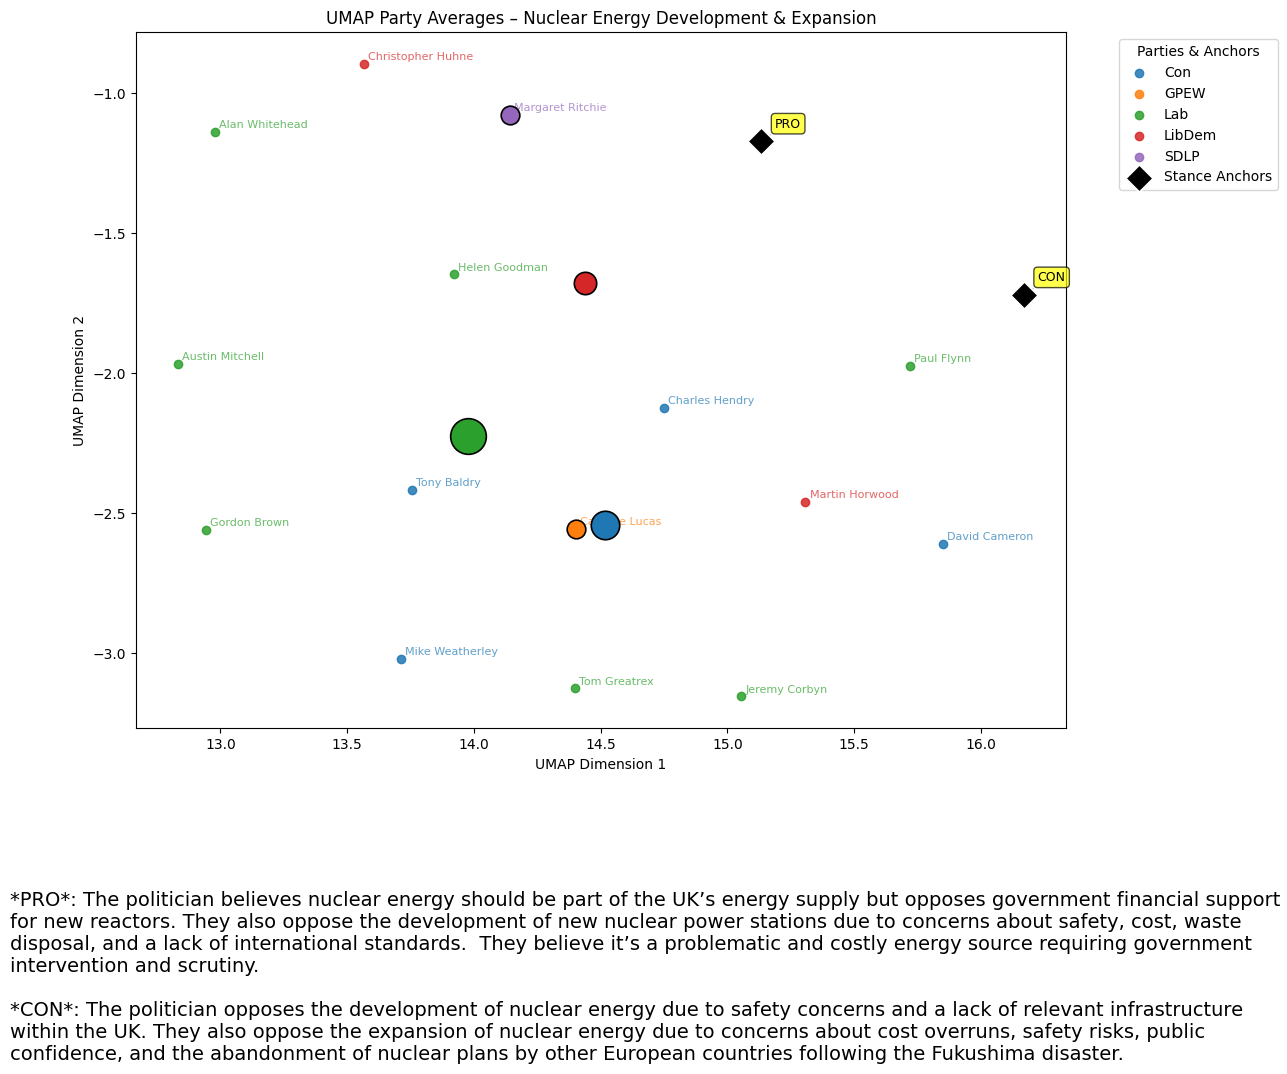

In [60]:
embeddings = uk.compute_umap_embeddings('nuclear', anchors[0])
uk.plot_umap_party_averages(embeddings, 'nuclear')

In [30]:
politician_stance("Caroline Lucas")

'The politician opposes nuclear energy due to concerns about its safety, cost, and contribution to greenhouse gas emissions.'

Computing UMAP embeddings for topic: nuclear


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

/Users/andreacristiano/Desktop/VNIVERSITA/MAGISTRALE 2 ANNO/Big Data analytics/stance-detection-eu-parliaments/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


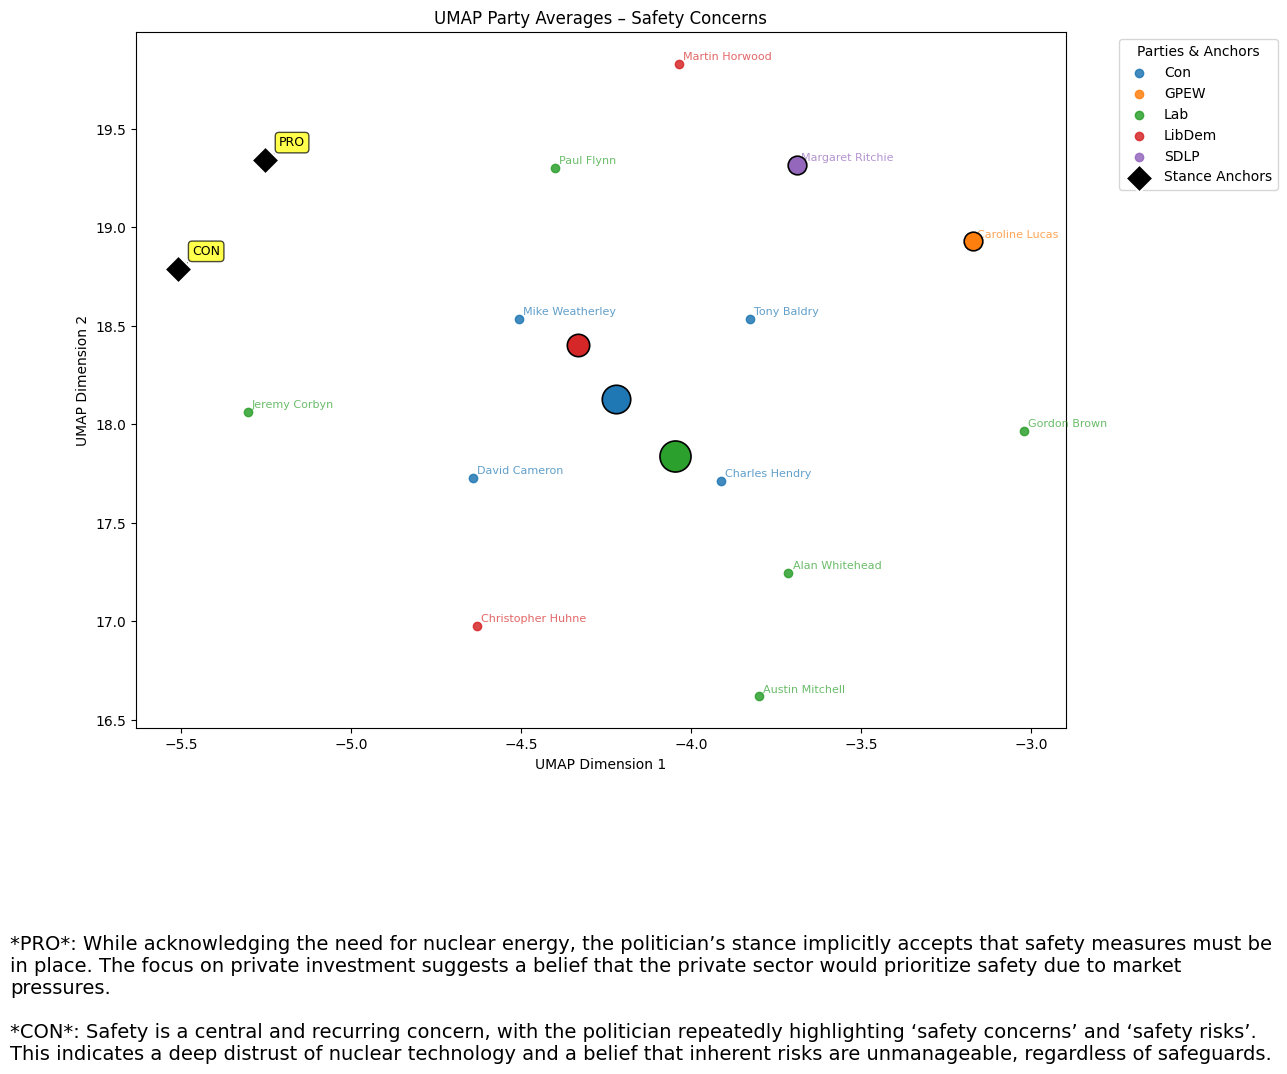

In [32]:
embeddings = uk.compute_umap_embeddings('nuclear', anchors[1])
uk.plot_umap_party_averages(embeddings, 'nuclear')

## Gaza

In [33]:
topic='Gaza'
filtered_df= uk.filter_speeches(topic, years=[2011, 2012, 2013, 2014])
classified_df = uk.classify_filtered_sentences(topic)
summarizations=uk.summarize_all_sentences(topic)
anchors=uk.generate_anchors(topic)

Filtering speeches for topic: Gaza
Number of speeches after filtering for topic 'Gaza' in years [2011, 2012, 2013, 2014]: 1547
Classifying filtered speeches for topic: Gaza
"Number of opinionated speeches for Gaza: 238
Summarization completed for topic: Gaza
Generating stance anchors for topic: Gaza


In [35]:
anchors

[{'topic': 'Hamas Disarmament & Palestinian Statehood',
  'pro': 'Advocates for dismantling Hamas and opposes Palestinian statehood until Hamas meets specific conditions (renouncing violence, recognizing Israel, accepting treaties). They view Hamas as a fundamental threat to Israel and Jewish people. They support a negotiated two-state solution contingent on Hamas’s rejection of Israel’s existence.',
  'con': 'The Foreign Secretary believes Israel’s actions undermine a two-state solution and advocates for Palestinian rights and equal treatment. Others advocate for elections in Gaza, reconciliation that doesn’t support Hamas, and a negotiated solution involving all parties, including the UN and EU.'},
 {'topic': 'Israeli Actions & Palestinian Suffering',
  'pro': 'Several politicians strongly condemn Israeli actions impacting Palestinians, highlighting civilian suffering, criticizing Israeli policies, settlement expansion, and the blockade of Gaza. They advocate for improved access and 

Computing UMAP embeddings for topic: Gaza


Batches:   0%|          | 0/2 [00:00<?, ?it/s]

/Users/andreacristiano/Desktop/VNIVERSITA/MAGISTRALE 2 ANNO/Big Data analytics/stance-detection-eu-parliaments/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


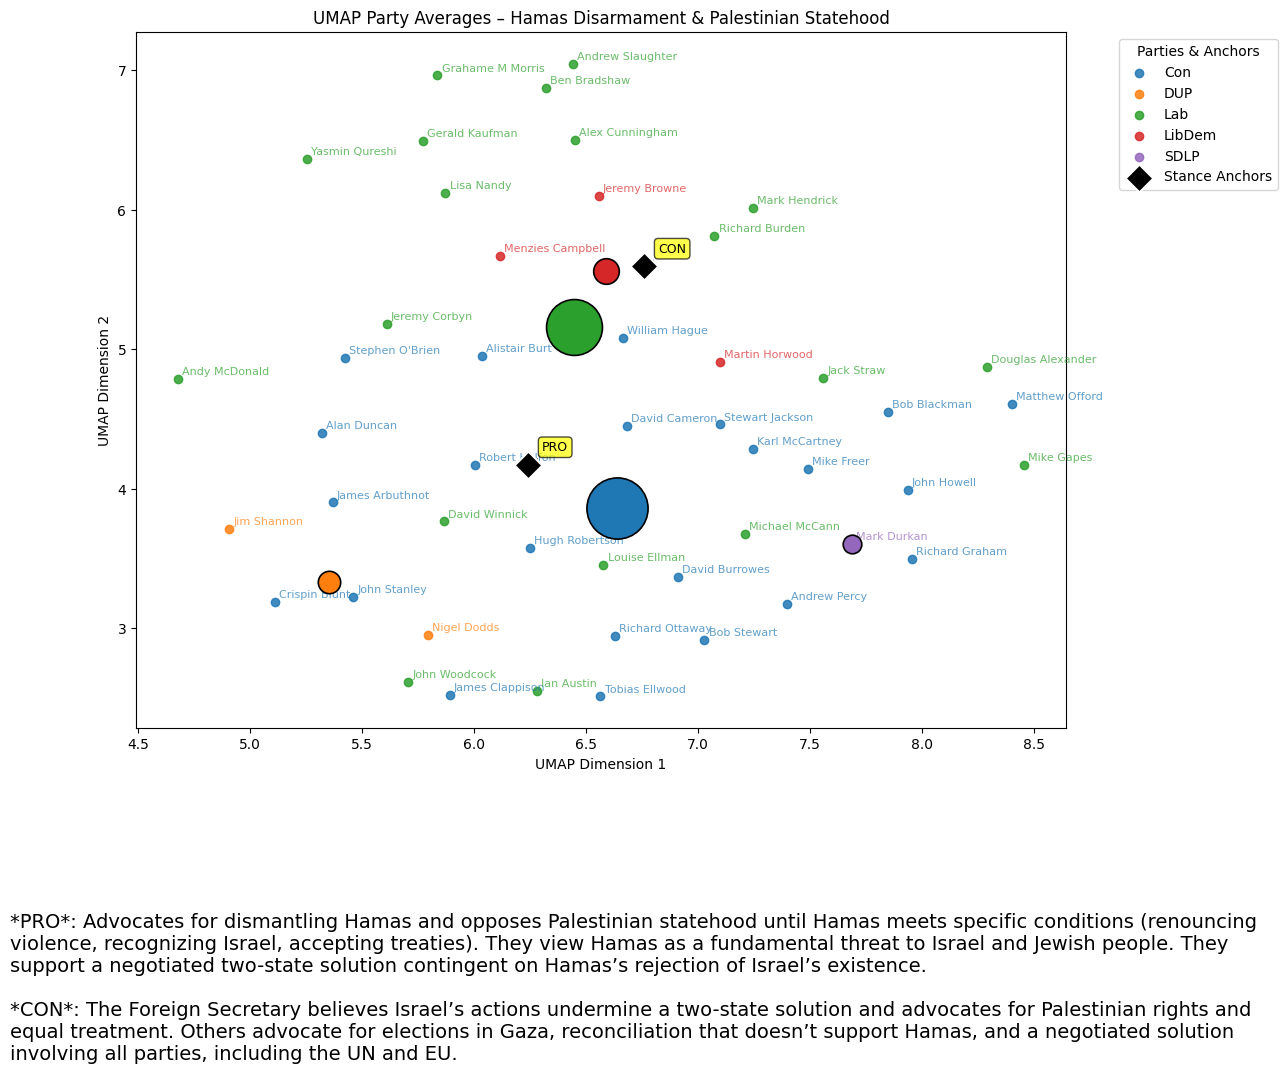

In [36]:
embeddings = uk.compute_umap_embeddings(topic, anchors[0])
uk.plot_umap_party_averages(embeddings, topic)

In [85]:
politician_stance(summarizations, "Jeremy Corbyn")

Jeremy Corbyn: Sarah Teather advocates for increased protection and support for asylum seekers, particularly vulnerable refugees, and opposes deportation policies that deny access to justice and adequate support.


#Results

In this case we can observe that the result of the analysys and embedding managed to create an easily readable figure. In this case we can observe quite a distinctive split in the opinions expressed by the two main parties. 
The Labour party more closely allignes with the CON stance, even though some Lab politicians do not fully fit this cluster. 
On the other hand all the Con politicians clearly allign with the Pro stance. 

Computing UMAP embeddings for topic: Gaza


Batches:   0%|          | 0/2 [00:00<?, ?it/s]

/Users/andreacristiano/Desktop/VNIVERSITA/MAGISTRALE 2 ANNO/Big Data analytics/stance-detection-eu-parliaments/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


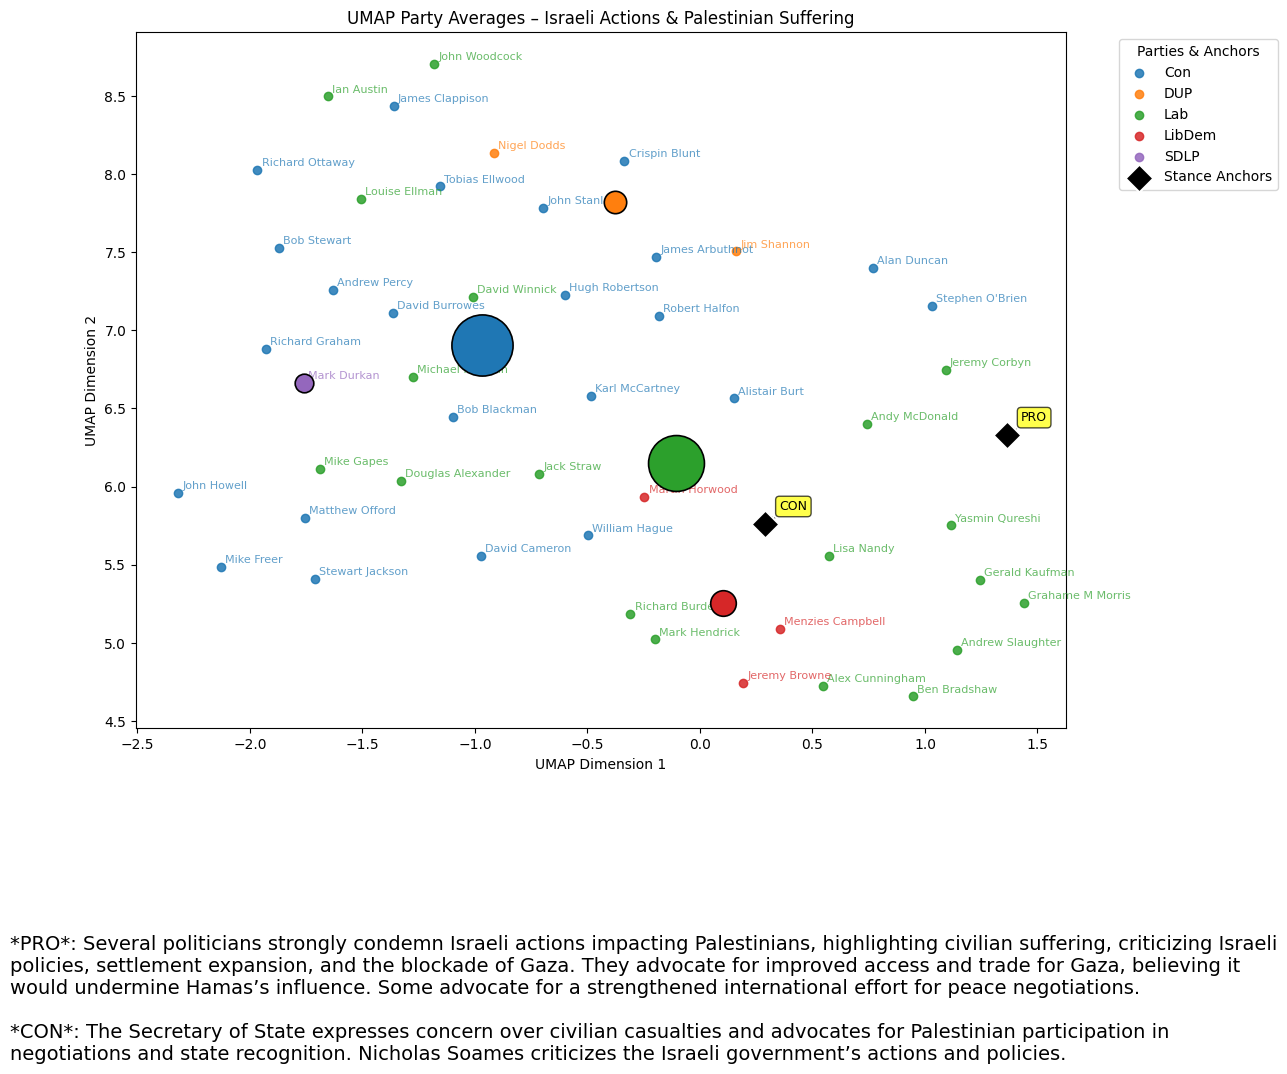

In [37]:
embeddings = uk.compute_umap_embeddings(topic, anchors[1])
uk.plot_umap_party_averages(embeddings, topic)

## Climate change

In [60]:
topic='climate change'

filtered_df= uk.filter_speeches(topic, years=[2011, 2012, 2013, 2014])

classified_df = uk.classify_filtered_sentences(topic)
summarizations=uk.summarize_all_sentences(topic)
anchors=uk.generate_anchors(topic)

Filtering speeches for topic: climate change
Number of speeches after filtering for topic 'climate change' in years [2011, 2012, 2013, 2014]: 1265
Classifying filtered speeches for topic: climate change
Number of opinionated speeches for topic climate change : 125
Summarization completed for topic: climate change
Generating stance anchors for topic: climate change


Computing UMAP embeddings for topic: climate change


Batches:   0%|          | 0/2 [00:00<?, ?it/s]

/Users/andreacristiano/Desktop/VNIVERSITA/MAGISTRALE 2 ANNO/Big Data analytics/stance-detection-eu-parliaments/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


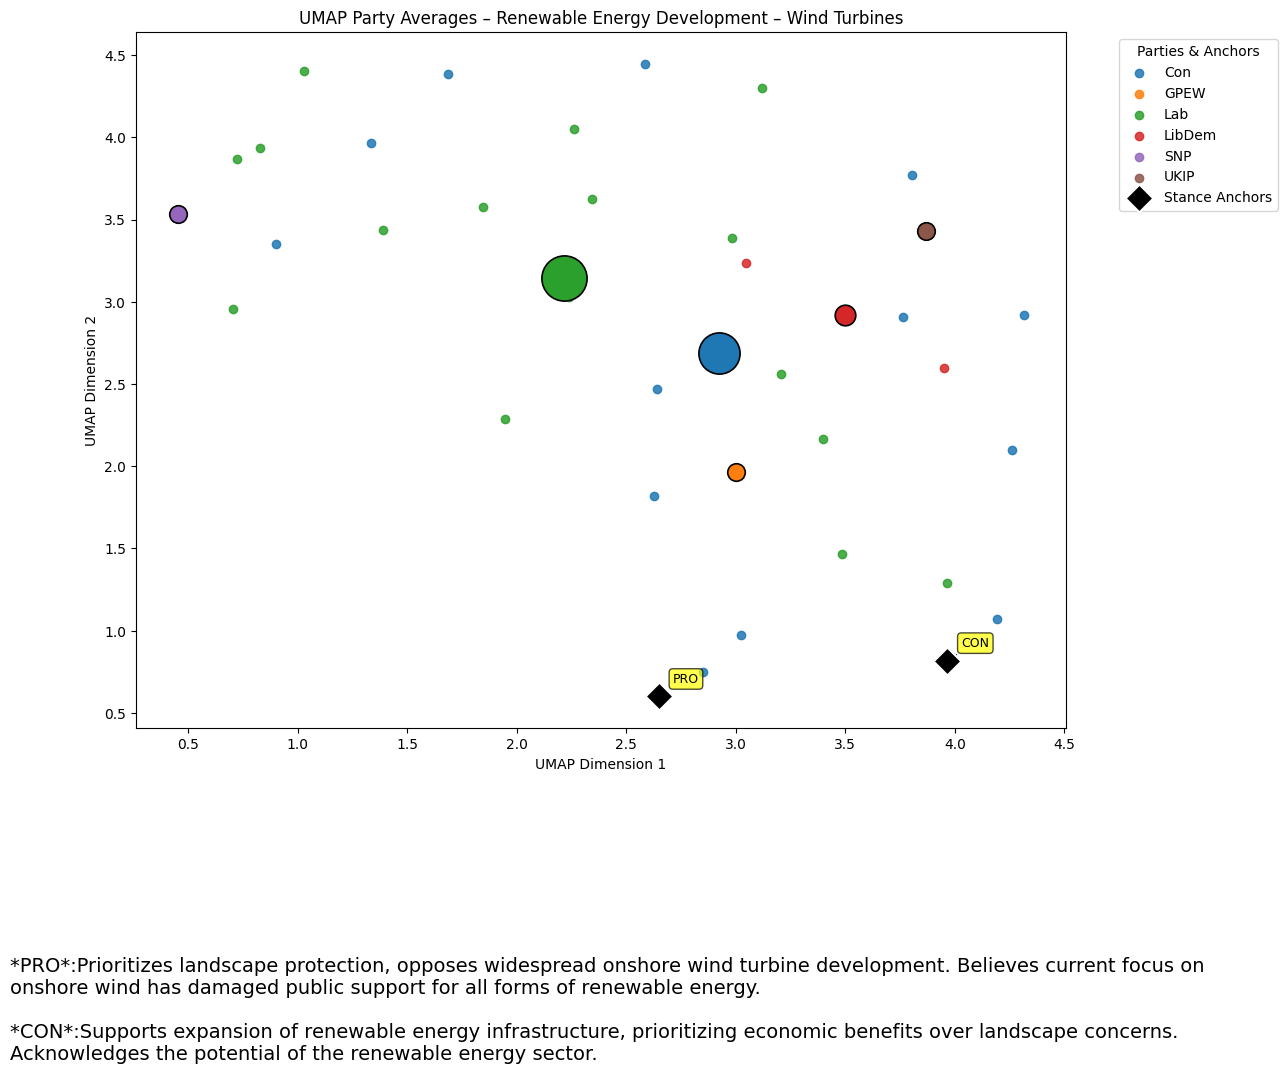

In [76]:
embeddings = uk.compute_umap_embeddings(topic, anchors[0])
uk.plot_umap_party_averages(embeddings, topic)

Computing UMAP embeddings for topic: climate change


Batches:   0%|          | 0/2 [00:00<?, ?it/s]

/Users/andreacristiano/Desktop/VNIVERSITA/MAGISTRALE 2 ANNO/Big Data analytics/stance-detection-eu-parliaments/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


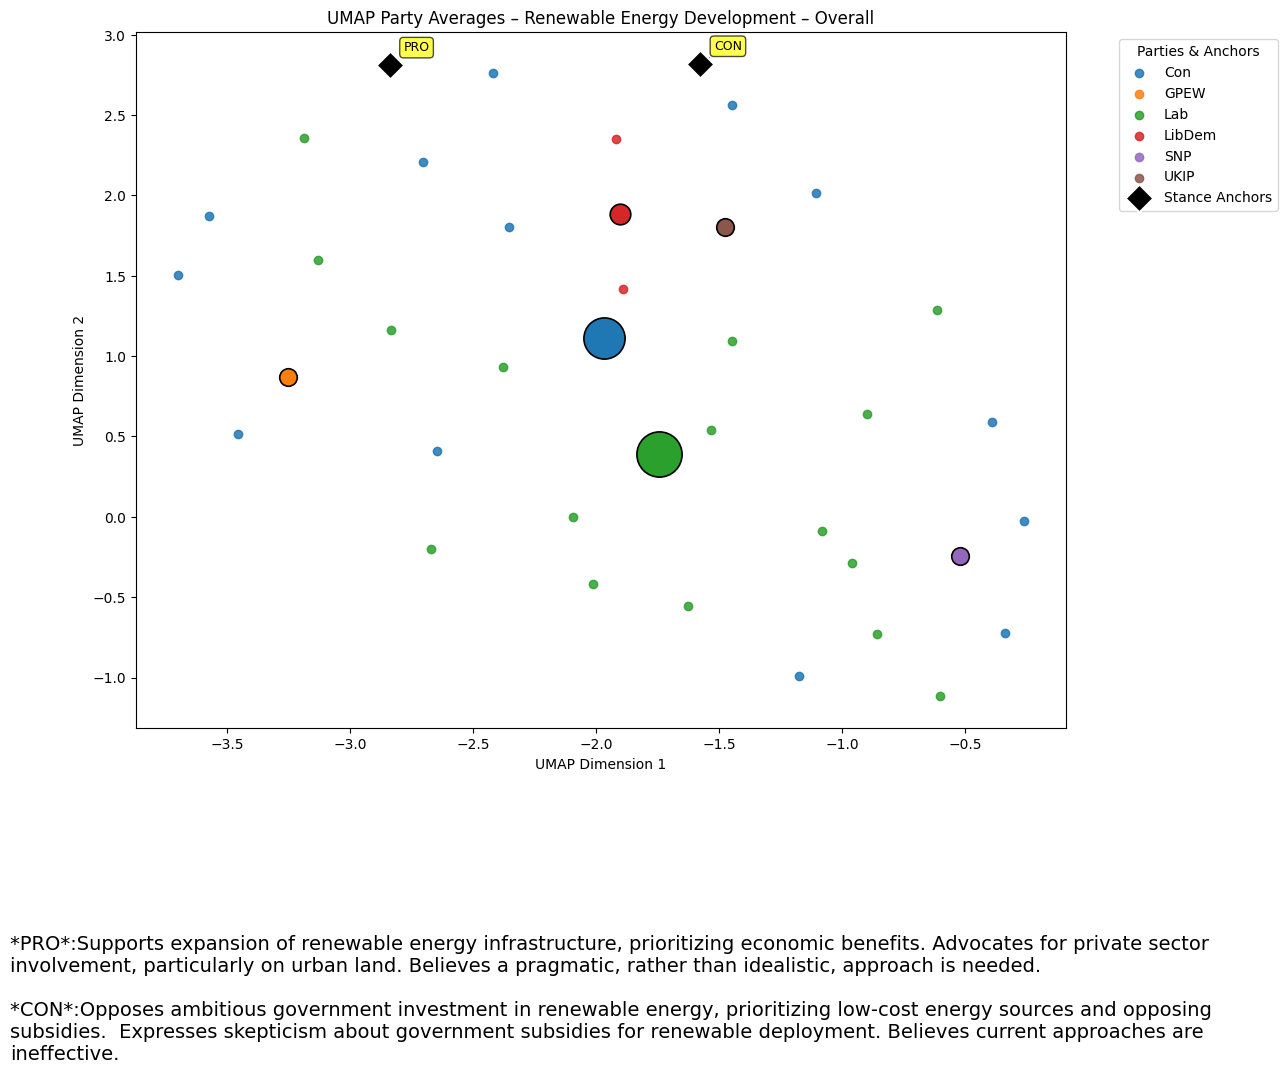

In [77]:
embeddings = uk.compute_umap_embeddings(topic, anchors[1])
uk.plot_umap_party_averages(embeddings, topic)

## Migration

In [67]:
topic='migration'
uk1=StanceDetector(df_1, records)
filtered_df= uk1.filter_speeches(topic, years=[2014])
classified_df = uk1.classify_filtered_sentences(topic)
summarizations=uk1.summarize_all_sentences(topic)
anchors=uk1.generate_anchors(topic)

Filtering speeches for topic: migration
Number of speeches after filtering for topic 'migration' in years [2014]: 6035
Classifying filtered speeches for topic: migration
Number of opinionated speeches for migration: 502
Summarization completed for topic: migration
Generating stance anchors for topic: migration


In [69]:
anchors

[{'topic': 'Migration Control & Restrictions',
  'pro': 'Stricter controls on immigration are necessary, particularly regarding individuals from outside the European Union. Migration should be tightly controlled, prioritizing the needs of those displaced by conflict. Increased enforcement of immigration laws, including criminalizing unauthorized entry, is crucial. Reduced net migration is a key goal, prioritizing border security and limiting asylum claims. Strict deportation policies should be implemented for individuals with criminal records abroad. Data limitations and concerns about undermining legal processes necessitate stricter controls.',
  'con': 'The government’s proposals for stricter controls are overly restrictive and inhumane. They risk damaging the UK’s reputation as a welcoming nation and fail to address the root causes of displacement. The focus should be on compassionate support for refugees and a more nuanced approach to managing migration flows. The pursuit of reduce

Computing UMAP embeddings for topic: migration


Batches:   0%|          | 0/4 [00:00<?, ?it/s]

/Users/andreacristiano/Desktop/VNIVERSITA/MAGISTRALE 2 ANNO/Big Data analytics/stance-detection-eu-parliaments/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


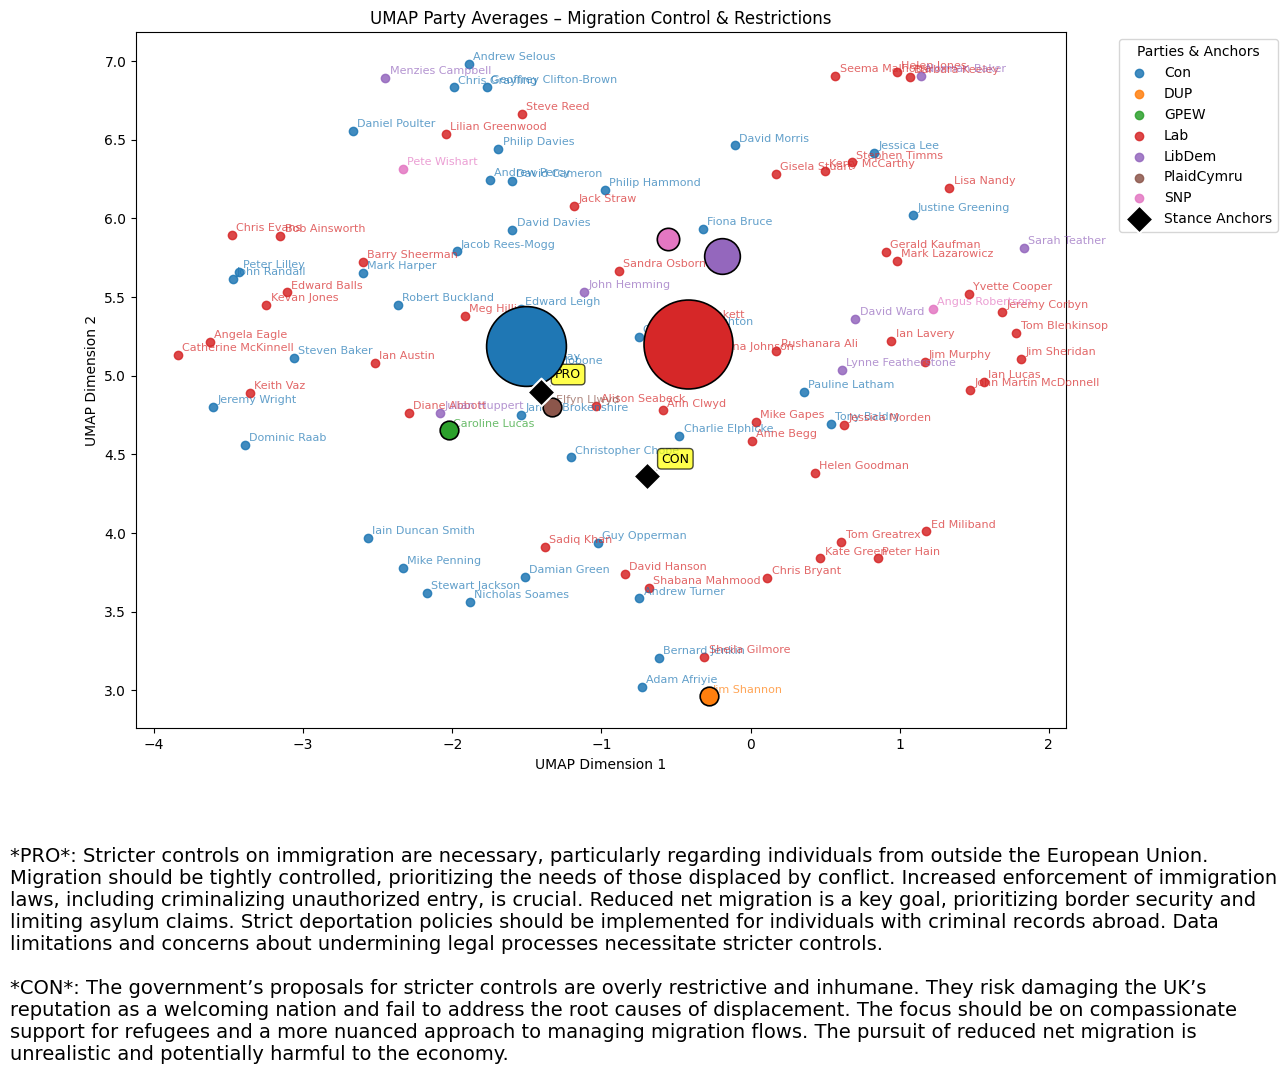

In [70]:
embeddings = uk1.compute_umap_embeddings(topic, anchors[0])
uk1.plot_umap_party_averages(embeddings, topic)

In [80]:
politician_stance(summarizations, "Jim Sheridan")
politician_stance(summarizations, "Robert Buckland")
politician_stance(summarizations, "Mike Penning")
politician_stance(summarizations, "Chris Bryant")
politician_stance(summarizations, "Pauline Latham")
politician_stance(summarizations, "David Ward")

Jim Sheridan: The politician advocates for increased support and protection for young asylum seekers, criticizing the government’s policies as creating a system that traps individuals in poverty and prevents them from integrating into society.
Robert Buckland: The politician advocates for strict immigration controls and opposes policies that may encourage asylum seekers to disappear.
Mike Penning: The politician believes high levels of immigration, particularly from the EU, negatively impact social cohesion and access to benefits for newcomers.
Chris Bryant: The politician believes that the primary issue is individuals arriving in the UK who circumvent immigration processes and that government projections regarding net migration figures are inaccurate.
Pauline Latham: The politician advocates for a managed approach to migration, prioritizing order and stability, and suggesting responsibility for refugee support lies with countries facing immediate challenges.
David Ward: The Deputy Pri

Computing UMAP embeddings for topic: migration


Batches:   0%|          | 0/4 [00:00<?, ?it/s]

/Users/andreacristiano/Desktop/VNIVERSITA/MAGISTRALE 2 ANNO/Big Data analytics/stance-detection-eu-parliaments/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


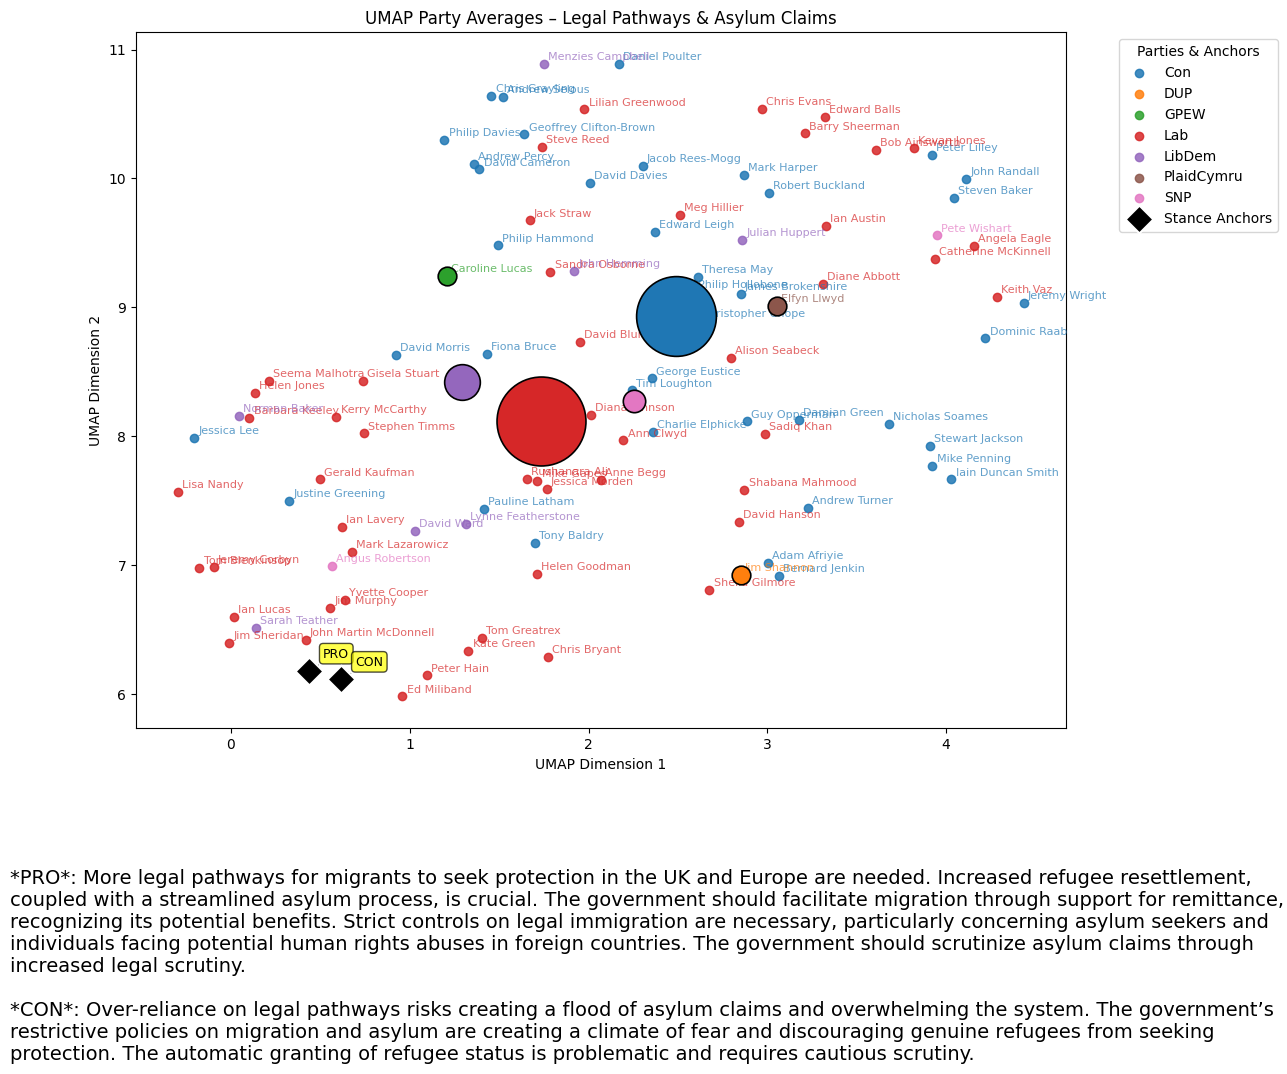

In [83]:
embeddings = uk1.compute_umap_embeddings(topic, anchors[4])
uk1.plot_umap_party_averages(embeddings, topic)

Computing UMAP embeddings for topic: migration


Batches:   0%|          | 0/4 [00:00<?, ?it/s]

/Users/andreacristiano/Desktop/VNIVERSITA/MAGISTRALE 2 ANNO/Big Data analytics/stance-detection-eu-parliaments/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


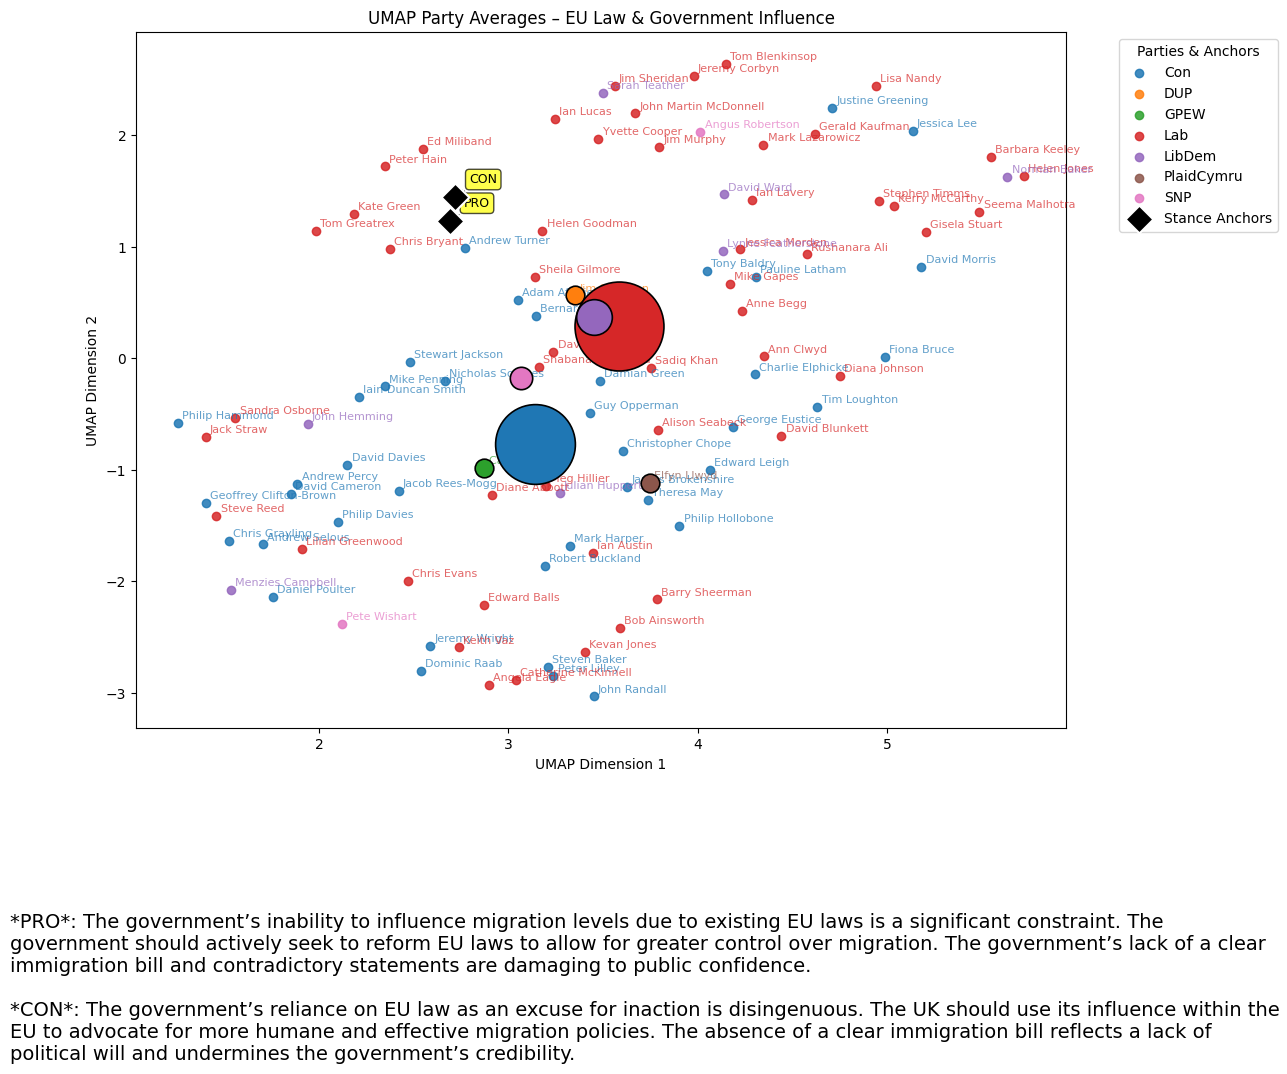

In [82]:
embeddings = uk1.compute_umap_embeddings(topic, anchors[2])
uk1.plot_umap_party_averages(embeddings, topic)